## Ano

In [1]:
# import pandas as pd
# df_list = []

# for year in range(2019,2025):
#     if year == 2019:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet"))
#     else:
#         df_list.append(pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet"))

In [2]:
# df = pd.concat(df_list)

# for year in range(2019,2025):
#     df.loc[str(year - 1):str(year)].to_parquet(f"../../data/02_clean/returns_{year-1}_{year}.parquet")

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm
import pickle
from functions import (
    corr_matrix, get_network_TMFG, build_and_save_graph
)

years = range(2019,2025)

# modes = {}

# for year in years:
#     modes[f"fast_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/fast_emd.parquet")
#     modes[f"medium_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/medium_emd.parquet")
#     modes[f"slow_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/slow_emd.parquet")

returns = {}

for year in years:
    returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
    returns[year] = np.log(1 + returns[year])
    
    # Drop columns with ALL NaNs upfront
    returns[year] = returns[year].dropna(axis=1, how='all')
    returns[year].drop(columns=["ABVC", "WKSP"], inplace=True)

common_cols = set(returns[years[0]].columns)
for year in years[1:]:
    common_cols &= set(returns[year].columns)

common_cols = sorted(list(common_cols))

# Apply common columns to all years
for year in years:
    original_cols = returns[year].shape[1]
    returns[year] = returns[year][common_cols]
    print(f"Year {year}: {original_cols} -> {returns[year].shape[1]} columns")

Year 2019: 404 -> 401 columns
Year 2020: 403 -> 401 columns
Year 2021: 404 -> 401 columns
Year 2022: 403 -> 401 columns
Year 2023: 404 -> 401 columns
Year 2024: 403 -> 401 columns


In [11]:
temp = pd.concat(returns).reset_index().set_index("Date").drop(columns=["level_0"])
temp.to_csv("../../data/02_clean/returns_clean_401.csv")

In [4]:
# corr = {}

# for year in years:
#     corr[f"corr_fast_{year}"] = corr_matrix(modes[f"fast_{year}"])
#     corr[f"corr_medium_{year}"] = corr_matrix(modes[f"medium_{year}"])
#     corr[f"corr_slow_{year}"] = corr_matrix(modes[f"slow_{year}"])

corr = {}

for year in years:
    corr[year] = corr_matrix(returns[year])

In [5]:
def exponential_weights(t, tau=125):
    """
    Generate exponential weights: w_t = w_0 * exp(-t/tau)
    Normalized so sum(w) = 1
    
    Parameters:
    -----------
    t : int
        Length of time window
    tau : int
        Characteristic time horizon (half-life)
    
    Returns:
    --------
    weights : array
        Exponential weights (most recent = highest weight)
    """
    # Time indices (0 = oldest, t-1 = most recent)
    time_idx = np.arange(t)
    
    # Exponential decay (recent events have higher weight)
    weights = np.exp(-time_idx / tau)
    weights = weights / weights.sum()  # Normalize
    
    # Reverse so most recent has highest weight
    return weights[::-1]

def weighted_correlation(returns, weights):
    """
    Compute weighted Pearson correlation matrix.
    
    Parameters:
    -----------
    returns : DataFrame
        Returns data (rows=time, columns=stocks)
    weights : array
        Time weights (same length as returns)
    
    Returns:
    --------
    corr_matrix : DataFrame
        Weighted correlation matrix
    """
    # Weighted mean
    weighted_mean = (returns * weights[:, None]).sum(axis=0)
    
    # Center the data
    centered = returns - weighted_mean
    
    # Weighted covariance
    weighted_cov = (centered.T @ (centered * weights[:, None])) / weights.sum()
    
    # Convert to correlation
    std = np.sqrt(np.diag(weighted_cov))
    corr = weighted_cov / np.outer(std, std)
    
    return pd.DataFrame(corr, index=returns.columns, columns=returns.columns)


def shrinkage_correlation(corr_matrices):
    """
    Apply shrinkage to average correlation matrix (Eq. 1 from paper).
    
    Averages correlation matrices over time window and shrinks toward
    the grand mean correlation.
    
    Parameters:
    -----------
    corr_matrices : list of DataFrames
        List of correlation matrices over time window
    
    Returns:
    --------
    shrunk_corr : DataFrame
        Shrinkage-adjusted correlation matrix
    """
    # Average the correlation matrices
    avg_corr = sum(corr_matrices) / len(corr_matrices)
    
    # Compute grand mean correlation (off-diagonal only)
    n = len(avg_corr)
    upper_tri_indices = np.triu_indices(n, k=1)
    grand_mean = avg_corr.values[upper_tri_indices].mean()
    
    # Shrinkage formula from paper (Eq. 1)
    shrinkage_factor = 1 / (2 * (len(corr_matrices) + 1))
    
    shrunk = (1 - shrinkage_factor) * avg_corr.values + shrinkage_factor * grand_mean
    
    # Ensure diagonal = 1
    np.fill_diagonal(shrunk, 1.0)
    
    return pd.DataFrame(shrunk, index=avg_corr.index, columns=avg_corr.columns)

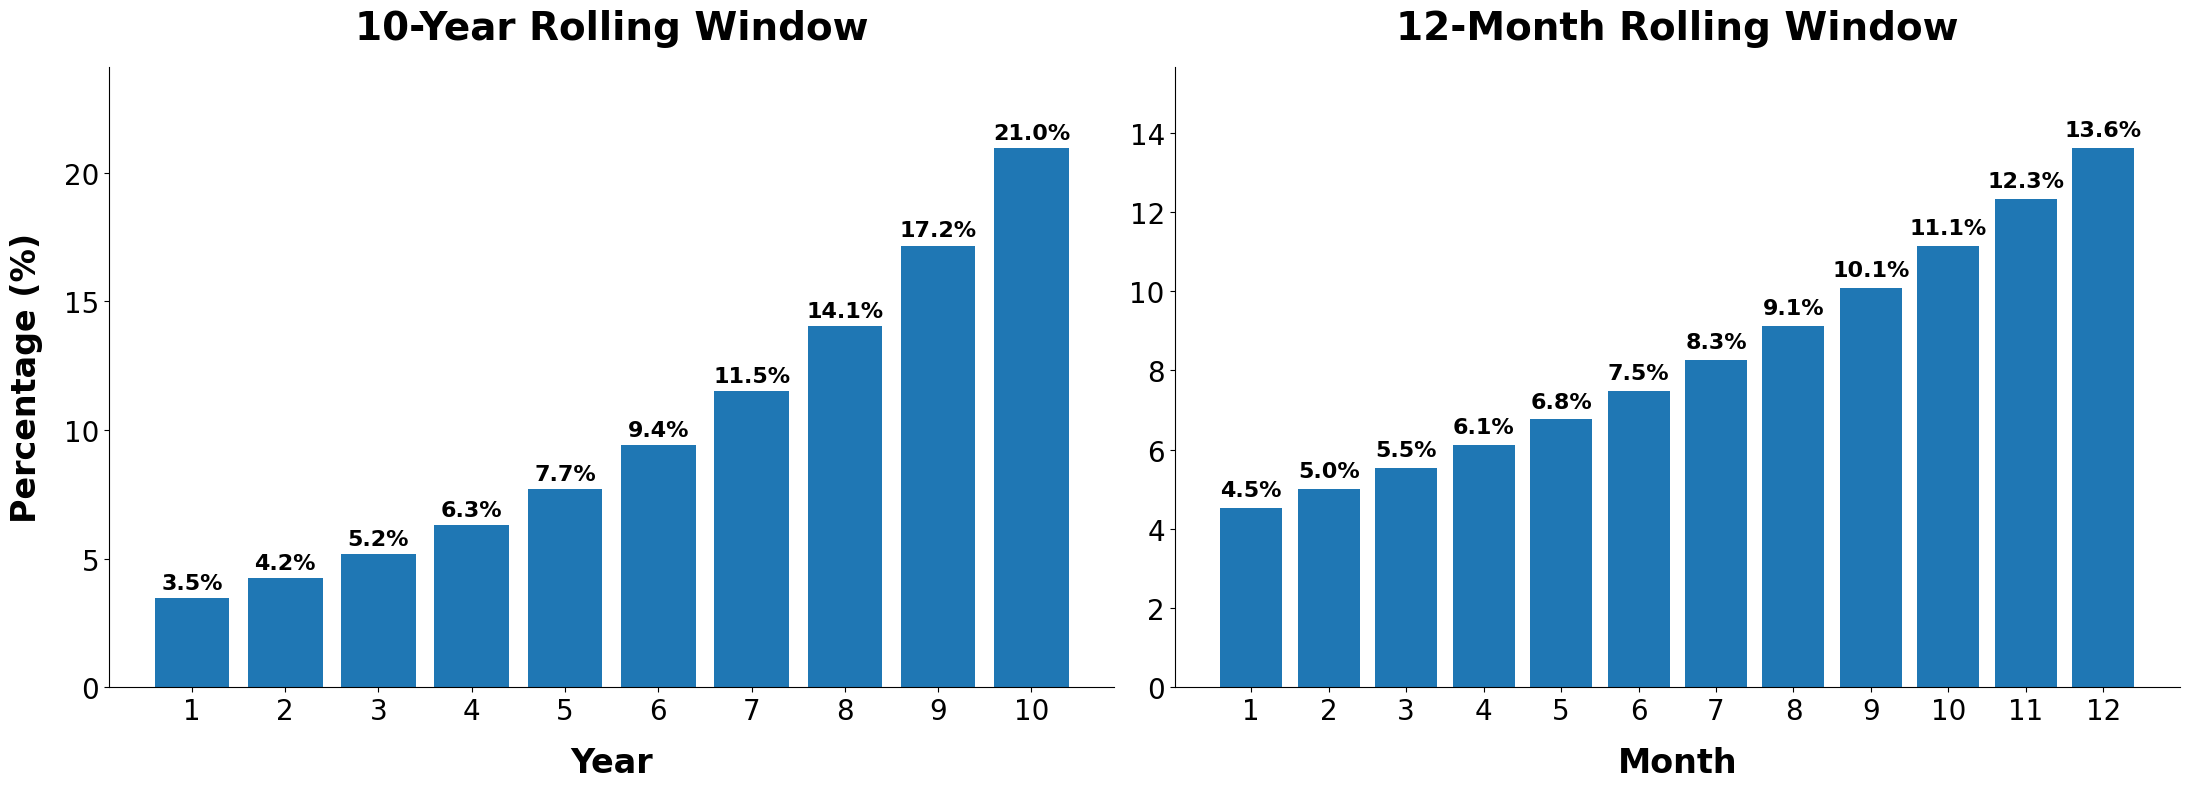

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming exponential_weights is defined elsewhere
w1 = exponential_weights(t=10, tau=5)
w2 = exponential_weights(t=12, tau=10)

# Convert to percentages
p1 = 100 * np.array(w1) / np.sum(w1)
p2 = 100 * np.array(w2) / np.sum(w2)

# --- FONT SIZE CONFIGURATION ---
TITLE_SIZE = 28
LABEL_SIZE = 24
TICK_SIZE = 20
ANNOTATION_SIZE = 16

fig, axes = plt.subplots(1, 2, figsize=(22, 8)) # Increased height for better proportions

# ---- First subplot (10-year) ----
bars1 = axes[0].bar(range(len(p1)), p1, linewidth=1.2)
axes[0].set_title("10-Year Rolling Window", fontsize=TITLE_SIZE, fontweight="bold", pad=20)
axes[0].set_ylabel("Percentage (%)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)
axes[0].set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)

axes[0].set_xticks(ticks=range(0, 10))
axes[0].set_xticklabels(range(1, 11), fontsize=TICK_SIZE)
axes[0].tick_params(axis='y', labelsize=TICK_SIZE)

# Add text on top of bars
for i, v in enumerate(p1):
    axes[0].text(i, v + 0.2, f"{v:.1f}%", ha='center', va='bottom', fontsize=ANNOTATION_SIZE, fontweight='bold')

# Increase y-limit to make room for text
axes[0].set_ylim(0, max(p1) * 1.15)


# ---- Second subplot (12-month) ----
bars2 = axes[1].bar(range(len(p2)), p2, linewidth=1.2)
axes[1].set_title("12-Month Rolling Window", fontsize=TITLE_SIZE, fontweight="bold", pad=20)
axes[1].set_xlabel("Month", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)

axes[1].set_xticks(ticks=range(0, 12))
axes[1].set_xticklabels(range(1, 13), fontsize=TICK_SIZE)
axes[1].tick_params(axis='y', labelsize=TICK_SIZE)

# Add text on top of bars
for i, v in enumerate(p2):
    axes[1].text(i, v + 0.2, f"{v:.1f}%", ha='center', va='bottom', fontsize=ANNOTATION_SIZE, fontweight='bold')

# Increase y-limit to make room for text
axes[1].set_ylim(0, max(p2) * 1.15)

# Clean up layout
sns.despine(fig=fig) # If you have seaborn imported, otherwise use axes[i].spines...
plt.tight_layout()
plt.savefig("../../figures/ew.png", dpi=300)
plt.show()

In [7]:
def compute_robust_corr(returns, years, tau, years_back):
    """
    Compute exponentially-weighted, shrunk correlation matrices for each year.

    Parameters
    ----------
    returns    : dict[int, pd.DataFrame]  — daily log-return DataFrames keyed by year
    years      : iterable[int]            — years to process
    tau        : float                    — decay parameter for exponential weights
    years_back : int                      — lookback horizon (>1 = annual windows, 1 = monthly)

    Returns
    -------
    robust_corr : dict[int, pd.DataFrame]
    """
    robust_corr = {}

    if years_back > 1:
        window_days = 252
        n_windows   = years_back
    else:  # years_back == 1
        window_days = 21
        n_windows   = 12

    for year in years:
        # print(f"{year}")
        temp        = returns[year]
        all_columns = temp.dropna(axis=1, how="all").columns
        t_idx       = len(temp) - 1

        corr_matrices_window = []

        for k in range(n_windows):
            window_end   = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start < 0:
                continue

            window       = temp.iloc[window_start:window_end]
            window_clean = window.dropna(axis=1, how="all").dropna(axis=0)

            if len(window_clean) >= window_days * 0.8:
                corr_matrices_window.append(window_clean.corr())

        corr_matrices_window = corr_matrices_window[::-1]  # chronological order

        if not corr_matrices_window:
            print(f"  No valid windows for {year}, skipping.")
            continue

        n_w = len(corr_matrices_window)
        across_weights   = exponential_weights(n_w, tau=tau)
        weighted_avg_corr = np.sum(
            [w * C for w, C in zip(across_weights, corr_matrices_window)],
            axis=0,
        )

        n               = len(weighted_avg_corr)
        upper_tri       = np.triu_indices(n, k=1)
        grand_mean      = weighted_avg_corr[upper_tri].mean()
        shrinkage_factor = 1 / (2 * (n_w + 1))

        shrunk = (1 - shrinkage_factor) * weighted_avg_corr + shrinkage_factor * grand_mean
        np.fill_diagonal(shrunk, 1.0)

        robust_corr[year] = pd.DataFrame(shrunk, index=all_columns, columns=all_columns)

    return robust_corr

In [8]:
def compute_robust_corr_lw(returns_dict: dict, years: range, tau: float, years_back: int) -> dict:
    """
    Compute exponentially-weighted correlation matrices using Ledoit-Wolf 
    shrunk covariances for each year.

    Parameters
    ----------
    returns_dict : dict[int, pd.DataFrame] — daily log-return DataFrames keyed by year
    years        : iterable[int]           — years to process
    tau          : float                   — decay parameter for exponential weights
    years_back   : int                     — lookback horizon (>1 = annual windows, 1 = monthly)

    Returns
    -------
    robust_corr : dict[int, pd.DataFrame]
    """
    robust_corr = {}

    if years_back > 1:
        window_days = 252
        n_windows   = years_back
    else:  # years_back == 1
        window_days = 21
        n_windows   = 12

    # Instantiate the Ledoit-Wolf model
    lw = LedoitWolf()

    for year in years:
        df = returns_dict[year]
        all_columns = df.columns
        t_idx = len(df) - 1

        cov_matrices_window = []

        # 1. Slice windows from most recent to oldest
        for k in range(n_windows):
            window_end   = t_idx - k * window_days
            window_start = window_end - window_days

            if window_start < 0:
                continue

            window_slice = df.iloc[window_start:window_end]
            # Drop rows with NaNs inside this specific window
            window_clean = window_slice.dropna(axis=0)

            if len(window_clean) >= window_days * 0.8:
                # 2. Fit Ledoit-Wolf to get the optimal shrunk covariance matrix
                # scikit-learn handles the optimization of the shrinkage intensity internally
                shrunk_cov = lw.fit(window_clean).covariance_
                cov_matrices_window.append(shrunk_cov)

        # Reverse to chronological order: oldest (index 0) to newest (index n_windows-1)
        cov_matrices_window = cov_matrices_window[::-1]

        if not cov_matrices_window:
            print(f"  No valid windows for {year}, skipping.")
            continue

        # 3. Apply exponential weights to the covariance matrices
        n_w = len(cov_matrices_window)
        across_weights = exponential_weights(n_w, tau=tau)

        weighted_avg_cov = np.sum(
            [w * cov for w, cov in zip(across_weights, cov_matrices_window)],
            axis=0
        )

        # 4. Convert the final weighted covariance matrix into a correlation matrix
        # C_ij = Sigma_ij / sqrt(Sigma_ii * Sigma_jj)
        vols = np.sqrt(np.diag(weighted_avg_cov))
        outer_vols = np.outer(vols, vols)
        final_corr = weighted_avg_cov / outer_vols

        # Force diagonal to exactly 1.0 to prevent floating point precision errors
        np.fill_diagonal(final_corr, 1.0)

        robust_corr[year] = pd.DataFrame(final_corr, index=all_columns, columns=all_columns)

    return robust_corr

In [12]:
robust_corr_10 = compute_robust_corr_lw(returns_dict=returns, years=range(2019,2025), tau=5, years_back=10)
robust_corr_1 = compute_robust_corr_lw(returns_dict=returns, years=range(2019,2025), tau=10, years_back=1)

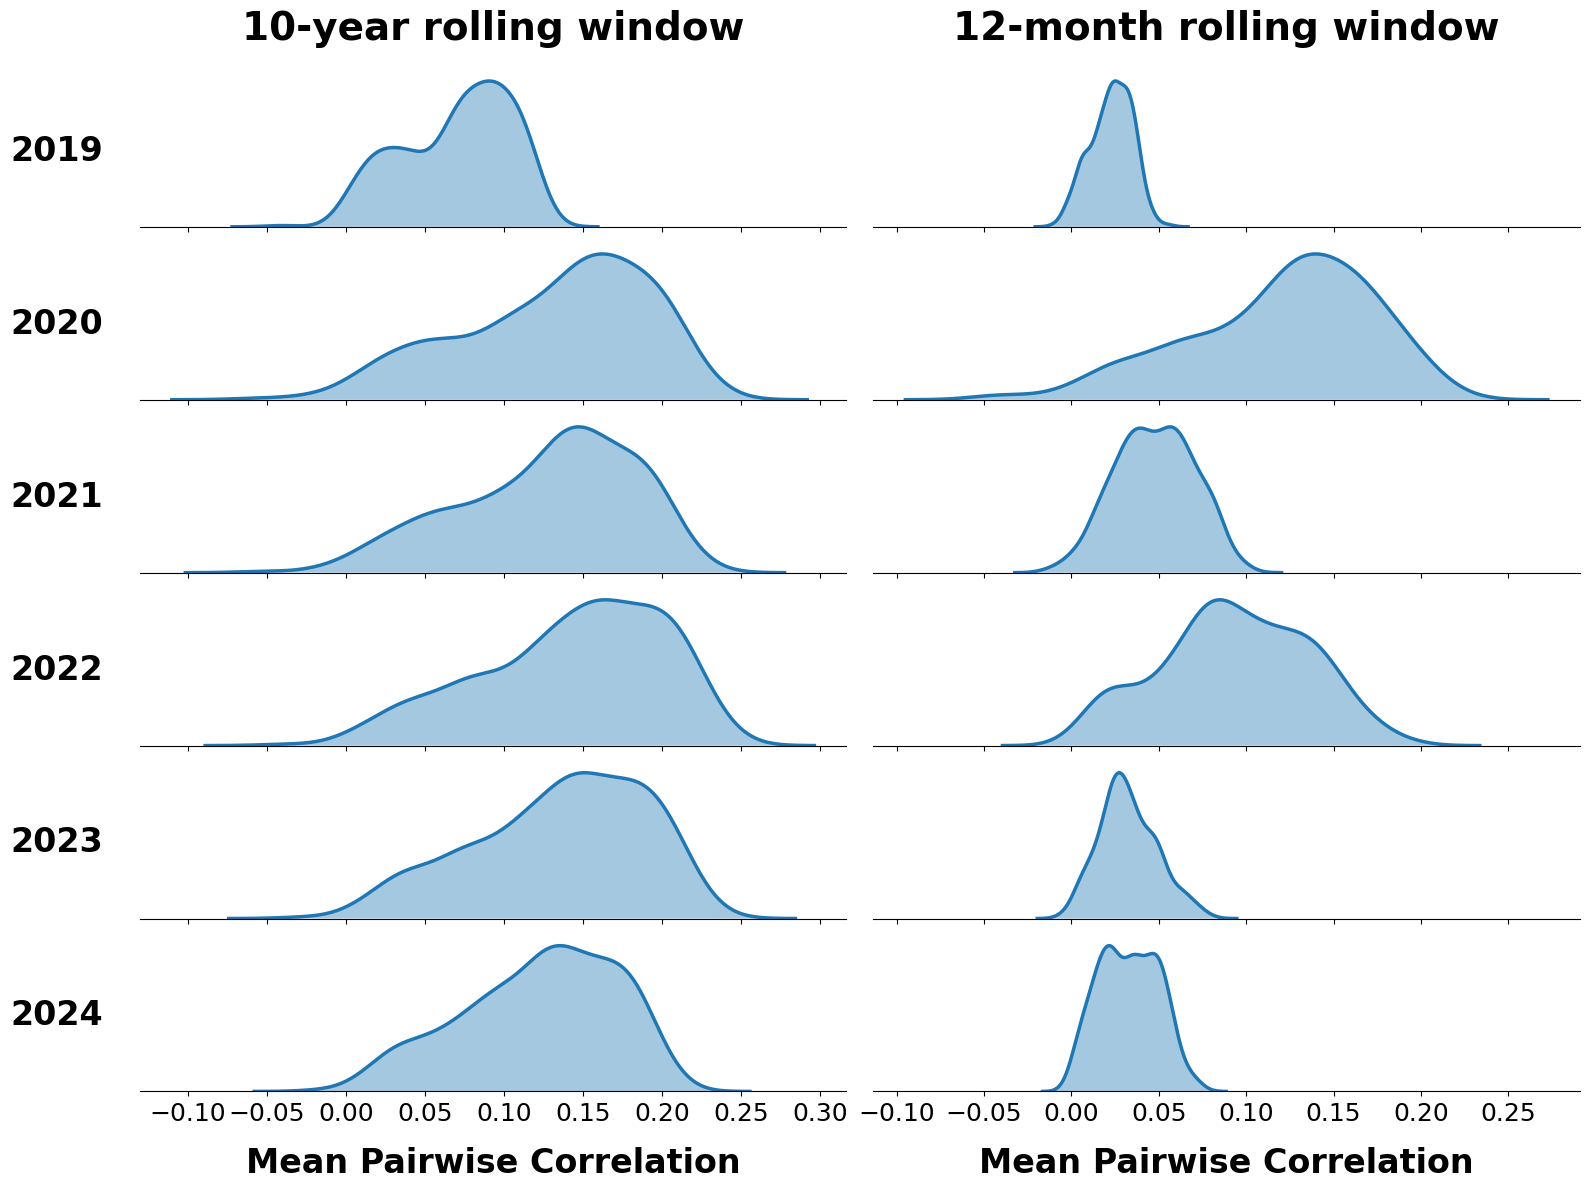

In [14]:
corr_dicts = {"10-year rolling window": robust_corr_10, "12-month rolling window": robust_corr_1}

# Increased figure height to accommodate larger row labels
fig, axes = plt.subplots(
    len(years), 2, 
    figsize=(16, len(years) * 2.0), 
    sharex="col"
)

# --- FONT SIZE CONFIGURATION ---
COLUMN_TITLE_SIZE = 28
ROW_LABEL_SIZE = 24
X_LABEL_SIZE = 24
TICK_SIZE = 18

for col_idx, (title, robust_corr) in enumerate(corr_dicts.items()):
    for row_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]
        data = robust_corr[year].mean()

        # KDE Plot
        sns.kdeplot(data, ax=ax)
        line = ax.get_lines()[0]
        x, y = line.get_data()
        ax.fill_between(x, y, alpha=0.4)
        line.set_linewidth(2.5)

        # Year label (Row Label) on the left column
        if col_idx == 0:
            # Increased labelpad so year doesn't touch the plot
            ax.set_ylabel(str(year), fontsize=ROW_LABEL_SIZE, fontweight="bold", 
                          rotation=0, labelpad=60, va="center")
        else:
            ax.set_ylabel("")

        # Cleaning up spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        
        # Increase x-tick size for all plots
        ax.tick_params(axis='x', labelsize=TICK_SIZE)

    # Column titles (Top row only)
    axes[0, col_idx].set_title(title, fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=25)

    # X-axis labels (Bottom row only)
    axes[-1, col_idx].set_xlabel("Mean Pairwise Correlation", fontsize=X_LABEL_SIZE, fontweight="bold", labelpad=15)

# Adjust spacing to prevent overlap between larger text elements
plt.subplots_adjust(hspace=-0.2) # Keeping the "joyplot" overlap look, adjust as needed
plt.tight_layout()
plt.savefig("../../figures/ridgeline.png")
plt.show()

In [17]:
graph = {}

# Lista de todas as tarefas (ano, velocidade)
tasks = [year for year in years]
years_back = 10

# Barra de progresso
for year in tqdm(tasks, desc="Construindo grafos"):
    # Recupera a matriz de correlação (DataFrame com nomes dos ativos)
    corr_matrix = robust_corr_10[year]

    # Constroi o grafo TMFG
    G = get_network_TMFG(corr_matrix)

    # Cria a pasta se não existir e salva
    base_path = f"../../data/04_graphs/{year}_{years_back}"
    os.makedirs(base_path, exist_ok=True)
    file_path = os.path.join(base_path, f"graph.gpickle")
    with open(file_path, "wb") as f:
        pickle.dump(G, f)

    # Armazena no dicionário
    graph[f"graph_{year}"] = G

Construindo grafos: 100%|██████████| 6/6 [00:59<00:00,  9.88s/it]


In [239]:
len(corr_matrices_window)

9